# 📈 S&P 500 Data Engineering Project

## Final Data Science Project Submission

# Step 0

## Team Members
1. Arijit Chakma  
2. MD Moksudul Haque  
3. MD Alamgir Hossain


In [1]:
# --- STEP 0: ENVIRONMENT SETUP ---
import os
from google.colab import drive, userdata

# 1. Mount Google Drive for persistent CSV storage
drive.mount('/content/drive')

# 2. Define your project path
BASE_PATH = '/content/drive/My Drive/SP500_Project/'
if not os.path.exists(BASE_PATH):
    os.makedirs(BASE_PATH)
    print(f"Created project folder: {BASE_PATH}")

# 3. Securely retrieve the API Key from Colab Secrets
try:
    API_KEY = userdata.get('AV_API_KEY')
    print("Alpha Vantage API Key successfully loaded from Secrets.")
except Exception as e:
    print("ERROR: Please add 'AV_API_KEY' to your Colab Secrets (Key icon).")
    API_KEY = None
    print(f"Details: {e}")

# 4. Install external libraries
!pip install alpha_vantage mplfinance bs4 lxml

from alpha_vantage.timeseries import TimeSeries

# 5. Import libraries
from matplotlib import style
import bs4 as bs
import matplotlib.pyplot as plt
import mplfinance as mpf
import numpy as np
import pandas as pd
import pickle
import requests
import time


Mounted at /content/drive
Alpha Vantage API Key successfully loaded from Secrets.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.1 MB/s eta 0:00:00


# Questions for Step 0
1. **Why is it considered a security risk to hardcode your API key directly into a script?**  
Hardcoding an API key is a security risk because anyone who can see the notebook or source code can copy and misuse the key. That can lead to unauthorized requests, rate-limit abuse, or even account suspension. A more professional practice is to store secrets securely in tools like Colab Secrets or environment variables.

2. **What happens to files saved in the default /content/ directory of a Google Colab notebook after the session ends?**  
Files saved in `/content/` are temporary. When the Colab runtime disconnects, restarts, or the session ends, those files are usually deleted. This means they should not be used for long-term project storage.

3. **Explain the purpose of drive.mount('/content/drive') in a professional data pipeline.**  
`drive.mount('/content/drive')` connects Google Drive storage to the Colab notebook so files can be read from and saved to persistent cloud storage. In a professional data pipeline, this is useful because raw data, processed files, and outputs remain available across notebook sessions instead of being lost when the temporary runtime resets.


# Step 1 : ROBUST DATA ACQUISITION


---

In [2]:
# 1. SETUP API OBJECT
# Use the API_KEY and BASE_PATH established in Step 0
ts = TimeSeries(key=API_KEY, output_format='pandas')

def fetch_and_audit(symbol='TSLA'):
    """
    Fetches stock data, performs a metadata audit, and validates data integrity.
    """
    try:
        print(f"Initiating API request for {symbol}...")

        # Request daily stock data using the compact output size
        data, meta_data = ts.get_daily(symbol=symbol, outputsize='compact')

        # METADATA AUDIT
        print("\n---Metadata Audit ---")
        for key, value in meta_data.items():
            print(f"{key}: {value}")

        # DATA INTEGRITY CHECK
        print("\n-- Data Integrity Report ---")
        print(f"Total Rows: {len(data)}")
        print("Missing values by column:")
        print(data.isnull().sum())

        # Sort chronologically for downstream steps
        data.sort_index(inplace=True)

        # PREVIEW DATA
        print("\n---Most Current Market Entries ---")
        print(data.tail(5))

        # DATA PERSISTENCE
        save_path = os.path.join(BASE_PATH, f"{symbol}_daily_raw.csv")
        data.to_csv(save_path)
        print(f"\n Saved raw data to: {save_path}")

        return data

    except Exception as e:
        # Basic error handling for rate limits
        error_message = str(e).lower()
        print("\n API ERROR:")
        if "call frequency" in error_message or "premium" in error_message:
            print("The Alpha Vantage API rate limit was reached. Please wait and try again later.")
        else:
            print(str(e))
        return None

# Execute Step 1
df_raw = fetch_and_audit('TSLA')


Initiating API request for TSLA...

---Metadata Audit ---
1. Information: Daily Prices (open, high, low, close) and Volumes
2. Symbol: TSLA
3. Last Refreshed: 2026-04-17
4. Output Size: Compact
5. Time Zone: US/Eastern

-- Data Integrity Report ---
Total Rows: 100
Missing values by column:
1. open      0
2. high      0
3. low       0
4. close     0
5. volume    0
dtype: int64

---Most Current Market Entries ---
            1. open  2. high  3. low  4. close    5. volume
date                                                       
2026-04-13  350.065   356.35  348.57    352.42   53617477.0
2026-04-14  357.670   367.63  354.77    364.20   59979607.0
2026-04-15  366.830   394.65  362.50    391.95  113810355.0
2026-04-16  393.810   394.06  381.80    388.90   63515136.0
2026-04-17  395.920   409.28  391.65    400.62   90640032.0

 Saved raw data to: /content/drive/My Drive/SP500_Project/TSLA_daily_raw.csv


# Questions for Step 1
1. **What is the difference between the get_daily and get_intraday endpoints in the Alpha Vantage API?**  
`get_daily` returns one record per trading day, which is useful for daily trend analysis over weeks, months, or years. `get_intraday` returns market data at smaller intervals such as 1-minute, 5-minute, or 60-minute periods, which is better for short-term or within-day analysis.

2. **Why is it important to print and review the meta_data dictionary before processing the actual stock prices?**  
The `meta_data` dictionary confirms important context such as the symbol, last refreshed time, output size, and time zone. Reviewing it helps verify that the API returned the correct dataset before analysis begins, which reduces the risk of using stale, incomplete, or incorrect data.

3. **If the API returns a "Rate Limit" error, what code structure can you use to handle it without the script crashing?**  
A `try-except` block should be used so the script catches the exception instead of crashing. Inside the `except` block, the error message can be checked for phrases such as `"call frequency"` or `"premium"`, and the script can print a user-friendly message, wait, or retry later.


# Step 2: PLOTTING & INDEXING

---


Generating basic comprehensive chart for TSLA...


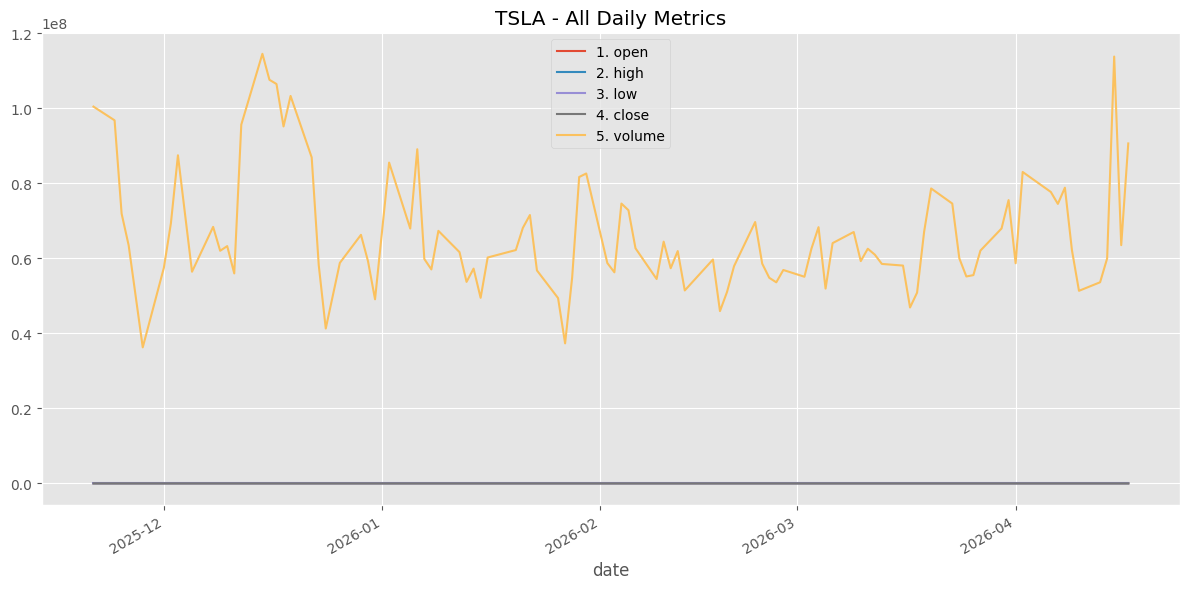

Generating Dual-Axis Price vs Volume chart for TSLA...


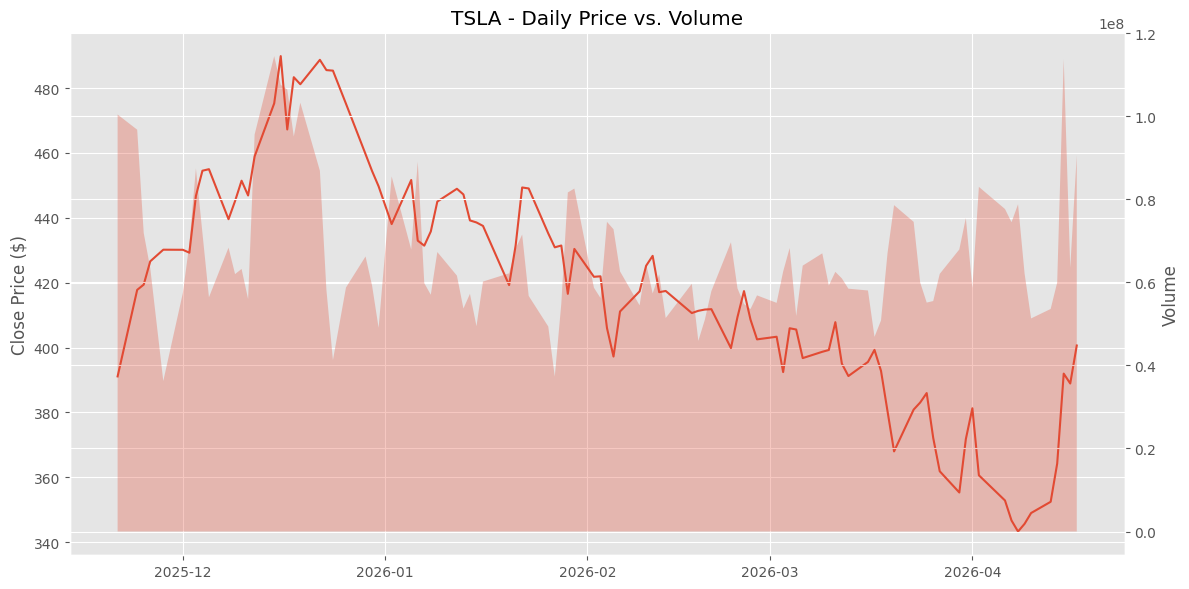

In [3]:
# Set visual style
style.use('ggplot')

def process_and_plot(symbol='TSLA'):
    """
    Cleans the raw CSV data and generates multi-axis visualizations.
    """
    # 1. LOAD DATA
    raw_path = os.path.join(BASE_PATH, f'{symbol}_daily_raw.csv')

    if not os.path.exists(raw_path):
        print("Error: CSV not found. Please run Step 1 first.")
        return

    # Load data with a DatetimeIndex
    df = pd.read_csv(raw_path, index_col='date', parse_dates=True)

    # DATA CLEANING
    df.sort_index(inplace=True)

    # COMPREHENSIVE PLOT
    print(f"Generating basic comprehensive chart for {symbol}...")
    df.plot(figsize=(12, 6), title=f"{symbol} - All Daily Metrics")
    plt.tight_layout()
    plt.show()

    # DUAL-AXIS VISUALIZATION
    print(f"Generating Dual-Axis Price vs Volume chart for {symbol}...")
    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(df.index, df['4. close'], label='Close Price')
    ax1.set_ylabel('Close Price ($)')

    ax2 = ax1.twinx()
    ax2.fill_between(df.index, df['5. volume'], alpha=0.3)
    ax2.set_ylabel('Volume')

    plt.title(f"{symbol} - Daily Price vs. Volume")
    plt.tight_layout()
    plt.show()

# Execute Step 2
process_and_plot('TSLA')


# Questions for Step 2
1. **Why do we need to sort the index of the DataFrame using df.sort_index(inplace=True) before plotting?**  
The API often returns stock records in reverse chronological order, with the newest dates first. Sorting the index places the data in true time order from oldest to newest so the line chart is drawn correctly and time-based analysis becomes easier to understand.

2. **What visualization problem occurs when you plot "Close Price" and "Volume" on the same Y-axis, and how do you fix it?**  
Volume values are usually much larger than stock prices, so plotting both on one Y-axis compresses the price line and makes it look almost flat. The professional fix is to use a secondary Y-axis with `twinx()` so price and volume each have their own scale.

3. **What is the benefit of setting the DataFrame index to a DatetimeIndex instead of leaving it as a standard string?**  
A `DatetimeIndex` allows pandas to treat the data as a time series. This makes it easier to sort dates, filter by time period, resample data, roll moving averages, and display a proper timeline on plots.


# Step 3: MOVING AVERAGES

---


--- Moving Average Preview (First 25 Rows) ---
            4. close   ma_line
date                          
2025-11-21    391.09       NaN
2025-11-24    417.78       NaN
2025-11-25    419.40       NaN
2025-11-26    426.58       NaN
2025-11-28    430.17       NaN
2025-12-01    430.14       NaN
2025-12-02    429.24       NaN
2025-12-03    446.74       NaN
2025-12-04    454.53       NaN
2025-12-05    455.00       NaN
2025-12-08    439.58       NaN
2025-12-09    445.17       NaN
2025-12-10    451.45       NaN
2025-12-11    446.89       NaN
2025-12-12    458.96       NaN
2025-12-15    475.31       NaN
2025-12-16    489.88       NaN
2025-12-17    467.26       NaN
2025-12-18    483.37       NaN
2025-12-19    481.20  446.9870
2025-12-22    488.73  451.8690
2025-12-23    485.56  455.2580
2025-12-24    485.40  458.5580
2025-12-26    475.19  460.9885
2025-12-29    459.64  462.4620
Generating Trend Analysis chart for TSLA...


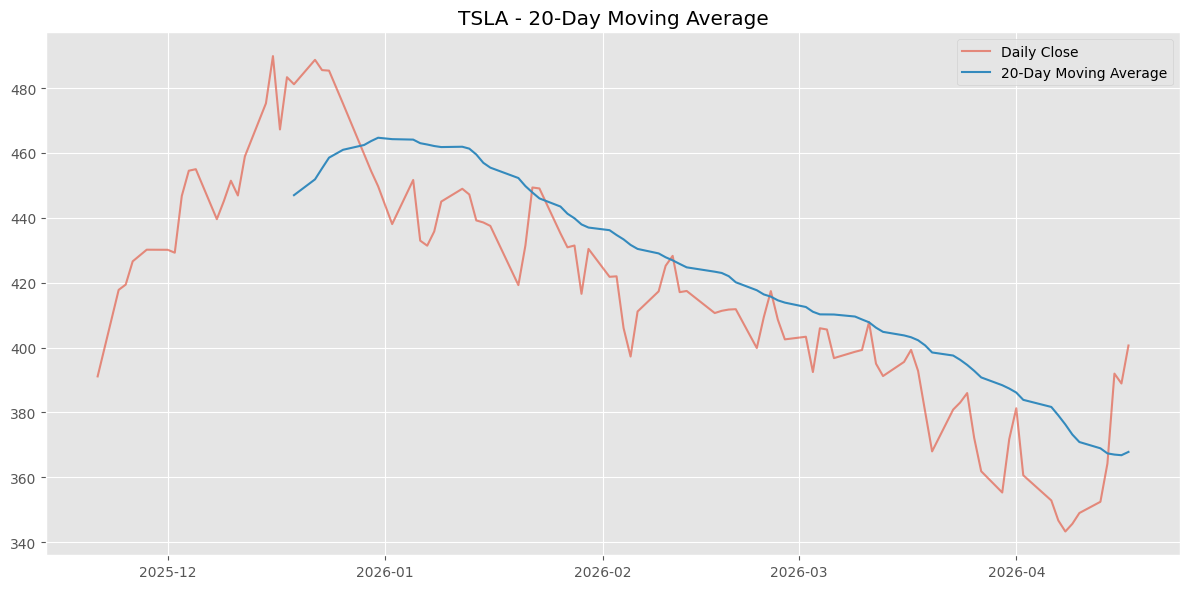

In [4]:
# --- STEP 3: TECHNICAL INDICATORS ---
import matplotlib.pyplot as plt
import pandas as pd
import os

def calculate_trend(symbol='TSLA'):
    """
    Calculates technical indicators and overlays them on price data.
    """
    # 1. LOAD DATA
    file_path = os.path.join(BASE_PATH, f'{symbol}_daily_raw.csv')

    if not os.path.exists(file_path):
        print("Error: Previous data not found.")
        return

    df = pd.read_csv(file_path, index_col='date', parse_dates=True)
    df.sort_index(inplace=True)

    # 2. CALCULATE MOVING AVERAGE
    df['ma_line'] = df['4. close'].rolling(window=20).mean()

    # DATA INSPECTION
    print("\n--- Moving Average Preview (First 25 Rows) ---")
    print(df[['4. close', 'ma_line']].head(25))

    # 3. VISUALIZATION
    print(f"Generating Trend Analysis chart for {symbol}...")
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['4. close'], label='Daily Close', alpha=0.6)
    plt.plot(df.index, df['ma_line'], label='20-Day Moving Average')
    plt.title(f"{symbol} - 20-Day Moving Average")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Execute Step 3
calculate_trend('TSLA')


# Questions for Step 3
1. **Why do the first several rows of a new "Moving Average" column contain NaN values?**  
The first rows contain `NaN` because a rolling average needs a full window of earlier observations before it can calculate a value. For a 20-day moving average, pandas needs 20 closing prices, so the first 19 rows do not yet have enough data.

2. **How does a Moving Average help a financial analyst compared to looking at the raw daily closing price?**  
A moving average smooths out short-term fluctuations and random daily noise, making the broader market trend easier to see. This helps analysts identify direction, momentum, and possible support or resistance zones more clearly than raw daily prices alone.

3. **What does the window parameter in df.rolling(window=X).mean() represent?**  
The `window` parameter represents the number of observations included in each rolling calculation. For example, `window=20` means each moving average point is based on the most recent 20 rows of data.


# Step 4a: CANDLESTICK CHARTS & RESAMPLING

---

Generating 10-Day Candlestick Chart for TSLA...


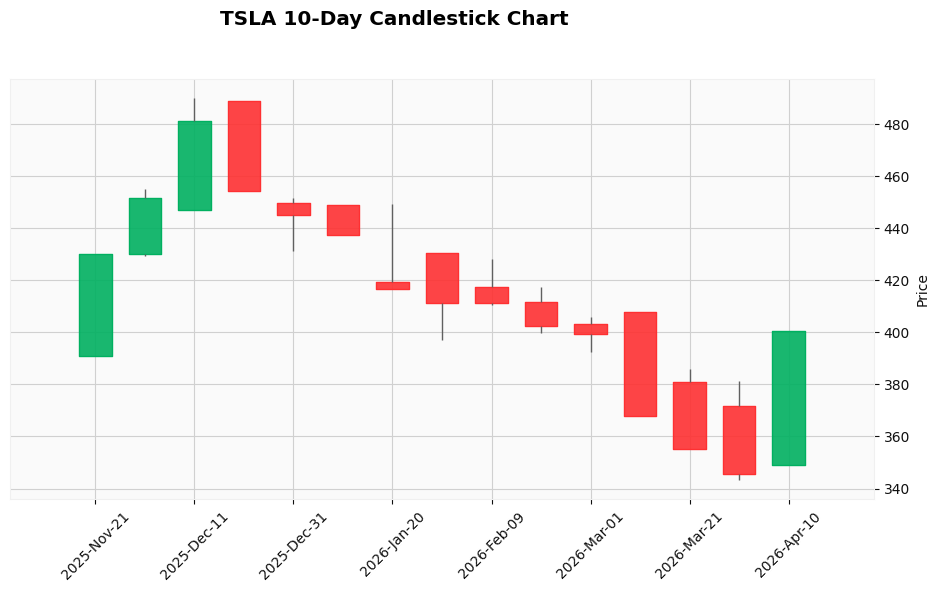

In [5]:
def generate_candlesticks(symbol='TSLA'):
    """
    Transforms daily data into 10-day OHLC bars and plots candlesticks.
    """
    # 1. LOAD DATA
    raw_path = os.path.join(BASE_PATH, f'{symbol}_daily_raw.csv')
    if not os.path.exists(raw_path):
        print("Error: Raw data CSV not found.")
        return

    df = pd.read_csv(raw_path, index_col='date', parse_dates=True)
    df.sort_index(inplace=True)

    # 2. DATA RESAMPLING
    ohlc_df = df['4. close'].resample('10D').ohlc()

    # Rename columns for mplfinance compatibility
    ohlc_df.columns = ['Open', 'High', 'Low', 'Close']

    # 3. VISUALIZATION
    print(f"Generating 10-Day Candlestick Chart for {symbol}...")
    mpf.plot(
        ohlc_df,
        type='candle',
        style='yahoo',
        title=f'{symbol} 10-Day Candlestick Chart',
        figsize=(12, 6)
    )

# Execute Step 4a
generate_candlesticks('TSLA')


# Step 4b: WEB SCRAPING & PICKLING

---

In [6]:
def save_sp500_tickers():
    """
    Scrapes Wikipedia for S&P 500 tickers and saves them as a pickle file.
    """
    print("Scraping S&P 500 ticker list from Wikipedia...")

    # 1. FETCH THE WEBPAGE
    resp = requests.get("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies", headers={"User-Agent": "Mozilla/5.0"})

    # 2. PARSE HTML
    soup = bs.BeautifulSoup(resp.text, "lxml")

    # Find the table with the id 'constituents'
    table = soup.find("table", {"id": "constituents"})

    tickers = []

    # 3. EXTRACT DATA
    for row in table.find_all("tr")[1:]:
        cols = row.find_all("td")
        if cols:
            ticker = cols[0].text.strip().replace(".", "-")
            tickers.append(ticker)

    # 4. DATA PERSISTENCE
    pickle_path = os.path.join(BASE_PATH, "sp500tickers.pickle")
    with open(pickle_path, "wb") as f:
        pickle.dump(tickers, f)

    print(f"Successfully saved {len(tickers)} tickers.")
    return tickers

# Execute Step 4b
tickers_list = save_sp500_tickers()


Scraping S&P 500 ticker list from Wikipedia...
Successfully saved 503 tickers.


# Questions for Step 4
1. **What information does a single "Candlestick" provide that a standard line chart does not?**  
A single candlestick shows four pieces of price information for a time period: open, high, low, and close. A standard line chart usually shows only one value, such as the closing price, so it does not reveal the full trading range or whether price moved up or down within that period.

2. **Explain the process of "Resampling" data from 1-day to 10-day intervals.**  
Resampling groups smaller time intervals into larger ones. In this project, daily closing-price data is grouped into 10-day periods and converted into OHLC values, where the first value becomes the open, the maximum becomes the high, the minimum becomes the low, and the last value becomes the close for each 10-day block.

3. **Why is it beneficial to "Pickle" the S&P 500 ticker list after scraping it from Wikipedia?**  
Pickling the ticker list saves the scraped results locally so the program can reload them quickly later without scraping the website again. This improves efficiency, reduces unnecessary web requests, and keeps the pipeline more reproducible.


# Step 5: AUTOMATED PIPELINE

In [7]:
# STEP 5: AUTOMATED PIPELINE ---
from alpha_vantage.timeseries import TimeSeries
import pandas as pd
import os
import time
import pickle

# 1. SETUP API & PATHS
ts = TimeSeries(key=API_KEY, output_format='pandas')
DATA_DIR = os.path.join(BASE_PATH, 'stock_dfs/')

# Ensure the DATA_DIR directory exists before proceeding
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
    print(f"Created data directory: {DATA_DIR}")

def compile_data(reload_sp500=False):
    """
    Automates data collection for 25 tickers and compiles them into a master CSV.
    """
    # 2. LOAD TICKER LIST
    ticker_path = os.path.join(BASE_PATH, 'sp500tickers.pickle')
    if reload_sp500 or not os.path.exists(ticker_path):
        save_sp500_tickers()

    with open(ticker_path, 'rb') as f:
        tickers = pickle.load(f)[:25]

    # --- PART 1: DATA ACQUISITION LOOP ---
    calls_made = 0
    for ticker in tickers:
        file_path = os.path.join(DATA_DIR, f"{ticker}.csv")

        # Check if the CSV already exists in DATA_DIR
        if not os.path.exists(file_path):
            try:
                print(f"Downloading data for {ticker}...")
                df, _ = ts.get_daily(symbol=ticker, outputsize='compact')
                df.sort_index(inplace=True)
                df.to_csv(file_path)
                calls_made += 1
                time.sleep(15)
            except Exception as e:
                print(f"Failed to fetch {ticker}: {e}")
        else:
            print(f"Using existing file for {ticker}")

    # PART 2: DATA COMPILATION ---
    print("\nCompiling master dataframe...")
    main_df = pd.DataFrame()

    for ticker in tickers:
        file_path = os.path.join(DATA_DIR, f"{ticker}.csv")

        if os.path.exists(file_path):
            temp_df = pd.read_csv(file_path, index_col='date', parse_dates=True)
            temp_df = temp_df[['4. close']].rename(columns={'4. close': ticker})

            if main_df.empty:
                main_df = temp_df
            else:
                main_df = main_df.join(temp_df, how='outer')

    # 3. SAVE THE MASTER FILE
    master_path = os.path.join(BASE_PATH, 'sp500_joined_closes.csv')
    main_df.to_csv(master_path)
    print(f"Master dataframe saved to: {master_path}")
    print(f"API calls made in this run: {calls_made}")

    return main_df

# Execute the final pipeline
master_df = compile_data()


Using existing file for MMM
Using existing file for AOS
Using existing file for ABT
Using existing file for ABBV
Using existing file for ACN
Using existing file for ADBE
Using existing file for AMD
Using existing file for AES
Using existing file for AFL
Using existing file for A
Using existing file for APD
Using existing file for ABNB
Using existing file for AKAM
Using existing file for ALB
Using existing file for ARE

Compiling master dataframe...
Master dataframe saved to: /content/drive/My Drive/SP500_Project/sp500_joined_closes.csv
API calls made in this run: 10


# Questions for Step 5
1. **How does checking os.path.exists() for a CSV file before calling the API help manage your project's "Code Quality"?**  
Checking `os.path.exists()` prevents unnecessary API calls when the data has already been saved locally. This improves efficiency, reduces repeated work, makes the notebook faster to rerun, and helps the code behave more predictably and professionally.

2. **Why is an "Outer Join" used when merging multiple stock DataFrames into one master file?**  
An outer join keeps all dates from all stock files, even when some companies are missing data on certain dates. This is helpful because different stocks may have incomplete histories or slightly different date coverage, and we do not want to lose useful records during the merge.

3. **What is the role of time.sleep(15) in a loop that makes multiple API requests?**  
`time.sleep(15)` pauses the loop between API requests so the script respects the free Alpha Vantage rate limits. Without that pause, the program is more likely to trigger a rate-limit error and fail during bulk data collection.
